In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
import os
sys.path.append(os.path.abspath('..'))
from data.yfinance_data import fetch_data
from config import TRAIN_END, EVAL_START, EVAL_END

In [2]:
data = fetch_data()

[*********************100%***********************]  1 of 1 completed


In [3]:
prices = data['Adj Close']
returns = np.log(prices/prices.shift(1)).dropna()
log_returns = returns * 100
log_returns.columns = ['Log Percentage Returns']

In [4]:
log_returns.head()

,Log Percentage Returns
Date,
2000-01-04,-3.909918
2000-01-05,0.192034
2000-01-06,0.095522
2000-01-07,2.672995
2000-01-10,1.112782


In [7]:
train_data = log_returns[:TRAIN_END]
eval_data = log_returns[EVAL_START:EVAL_END]

In [8]:
eval_data

,Log Percentage Returns
Date,
2013-01-02,2.508612
2013-01-03,-0.208780
2013-01-04,0.485330
2013-01-07,-0.312800
2013-01-08,-0.324764
...,...
2025-12-23,0.454007
2025-12-24,0.321630
2025-12-26,-0.030441


In [14]:
log_returns.iloc[:,0].mean()

np.float64(0.0238002034222972)

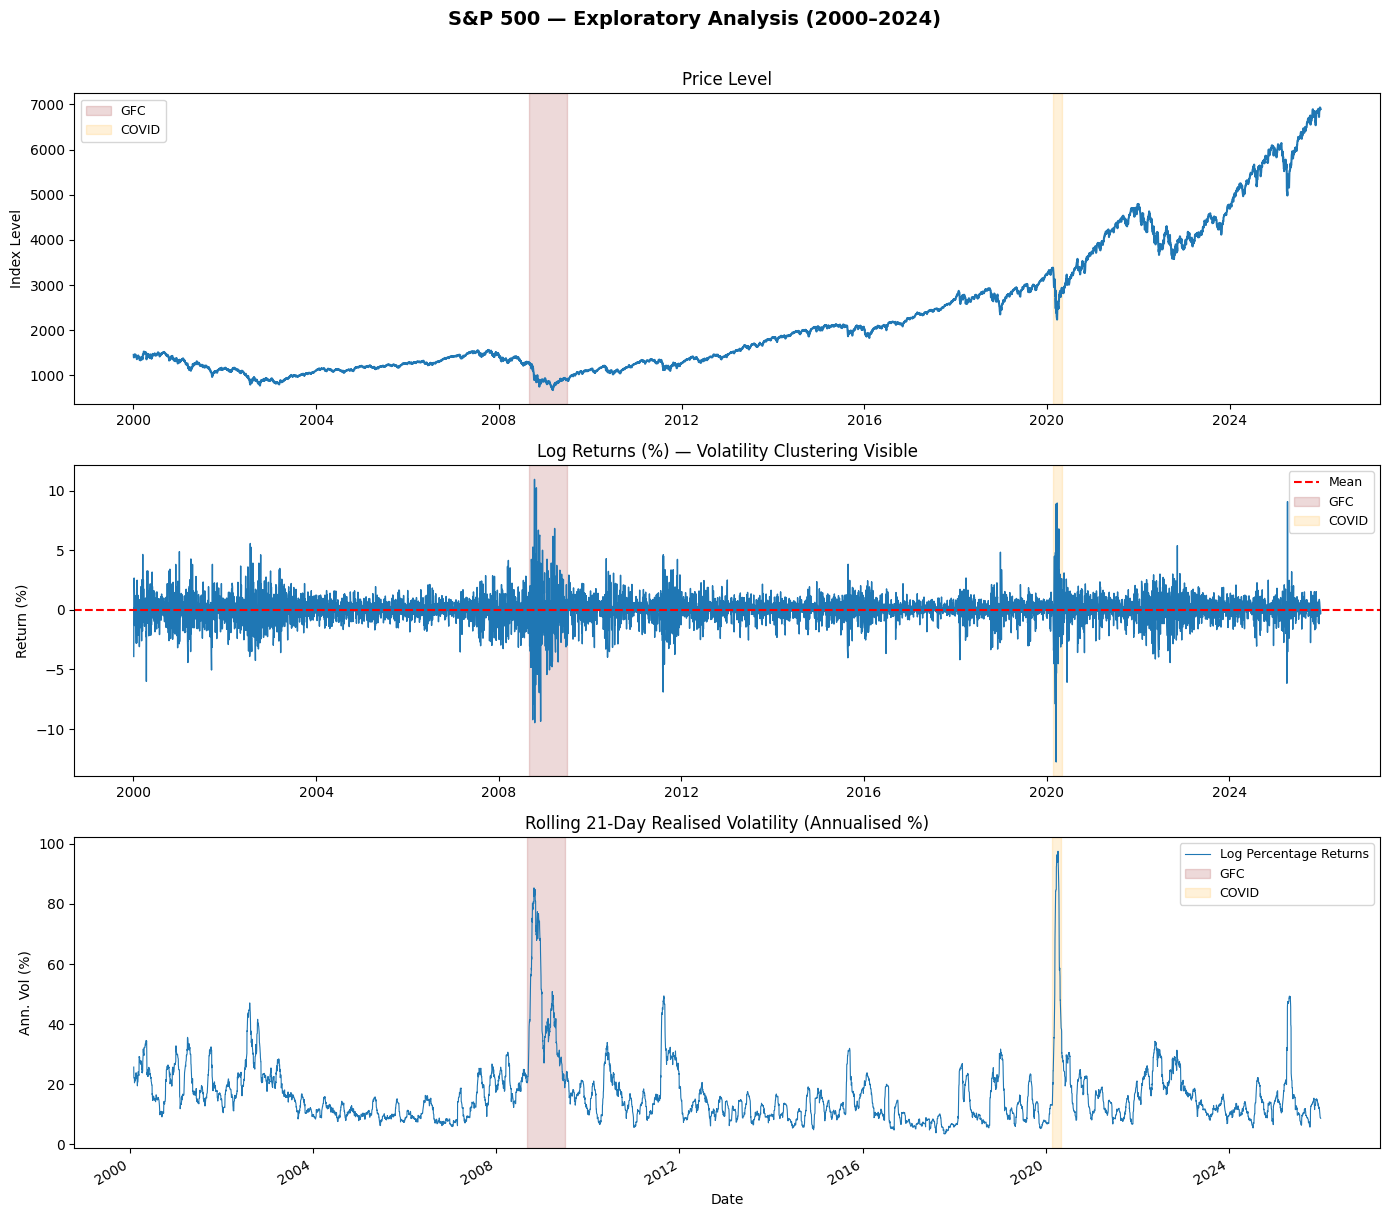

In [40]:
fig, axes = plt.subplots(3,1, figsize=(14,12))
fig.suptitle('S&P 500 — Exploratory Analysis (2000–2024)', fontsize=14, fontweight='bold', y=1.01)

ax = axes[0]
ax.plot(prices.index, prices.iloc[:,0])
ax.set_title('Price Level')
ax.set_ylabel('Index Level')
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='darkred', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color='orange', label='COVID')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(log_returns.index, log_returns.iloc[:,0], linewidth=1)
ax.set_title('Log Returns (%) — Volatility Clustering Visible')
ax.set_ylabel('Return (%)')
ax.axhline(log_returns.iloc[:,0].mean(), color='red', linestyle='--', label='Mean')
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='darkred', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color='orange', label='COVID')
ax.legend(fontsize=9)

ax = axes[2]
rv = log_returns.rolling(21).std() * np.sqrt(252)
rv.plot(ax=ax, linewidth=0.8)
ax.set_title('Rolling 21-Day Realised Volatility (Annualised %)')
ax.set_ylabel('Ann. Vol (%)')
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='darkred', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color="orange", label='COVID')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


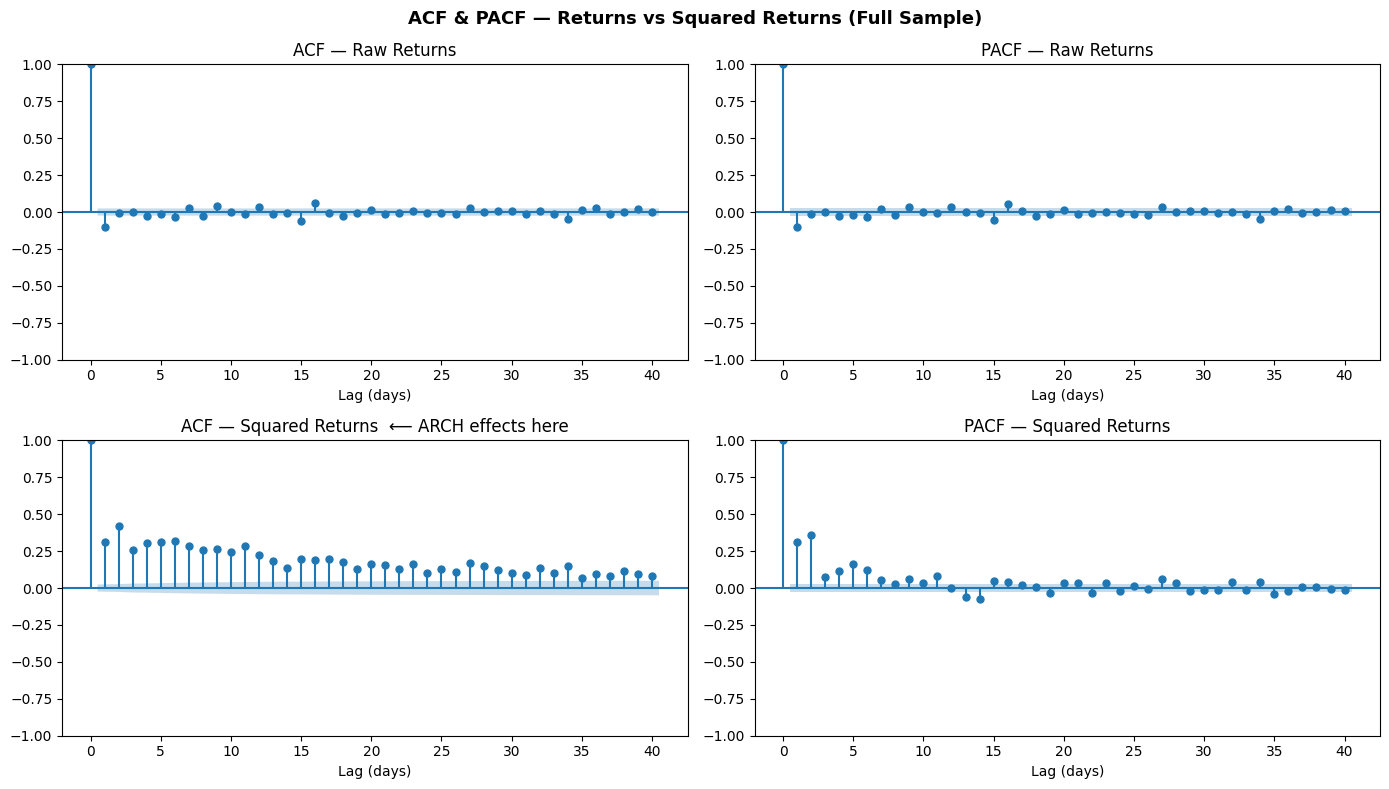

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF & PACF — Returns vs Squared Returns (Full Sample)', fontsize=13, fontweight='bold')

lags = 40

# Raw returns ACF
plot_acf(log_returns, lags=lags, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF — Raw Returns')
axes[0, 0].set_xlabel('Lag (days)')

# Raw returns PACF
plot_pacf(log_returns, lags=lags, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF — Raw Returns')
axes[0, 1].set_xlabel('Lag (days)')

# Squared returns ACF  ← This is where ARCH effects live
plot_acf(log_returns**2, lags=lags, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF — Squared Returns  ⟵ ARCH effects here')
axes[1, 0].set_xlabel('Lag (days)')

# Squared returns PACF
plot_pacf(returns**2, lags=lags, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF — Squared Returns')
axes[1, 1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()